# Orientation of actin filaments

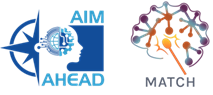

**Objective** <br>
Analyze actin fiber orientation in microscopy images by detecting lines and line segments using the Canny edge detector + standard and probabilistic Hough transforms, and quantifying orientation through circular statistics




**Relevant resources** <br>
[OpenCV: Canny Edge Detection](https://docs.opencv.org/3.4/da/d22/tutorial_py_canny.html) <br>
[OpenCV: Hough Line Transform](https://docs.opencv.org/3.4/d9/db0/tutorial_hough_lines.html)



**Acknowledgements** <br>
aiMATCH Hands-on Workshop Series: Computer vision for microscopy image analysis. NIH AIM AHEAD DICB Program <br>
Principal Investigator: Amina Qutub, Ph.D., University of Texas at San Antonio<br>
Workshop Presenters: David Hernandez-Guzman and Mignon Dumanjog, University of Texas at San Antonio<br> Code Author: Mignon Dumanjog, University of Texas at San Antonio<br>

# Import packages


In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import urllib.request
from scipy.stats import circmean, circstd
from ipywidgets import interact, IntSlider, Dropdown

# Load images
Use either option 1 or option 2.

**Option 1:** Access the photos through GitHub links (no downloads necessary)

In [ ]:
# Import images
img_A_path = 'https://github.com/qutublab/aiMATCH/releases/download/CV-microscopy-workshop/CellA_Actin.jpg'
img_B_path = 'https://github.com/qutublab/aiMATCH/releases/download/CV-microscopy-workshop/CellB_Actin.jpg'
img_C_path = 'https://github.com/qutublab/aiMATCH/releases/download/CV-microscopy-workshop/CellC_Actin.jpg'

def load_image_from_url(url):
    with urllib.request.urlopen(url) as url_response:
        img_array = np.array(bytearray(url_response.read()), dtype=np.uint8)
        img = cv2.imdecode(img_array, cv2.IMREAD_COLOR)
    return img

A = load_image_from_url(img_A_path)
B = load_image_from_url(img_B_path)
C = load_image_from_url(img_C_path)

# Check if images were loaded successfully
images_to_check = {'A': A, 'B': B, 'C': C}
image_paths = {'A': img_A_path, 'B': img_B_path, 'C': img_C_path}

for img_name, img_data in images_to_check.items():
    if img_data is None:
        raise FileNotFoundError(f"Error: Could not load image from {image_paths[img_name]}. Please ensure the file exists and the path is correct.")
    else:
        print(f"Image {img_name} loaded successfully.")

Image A loaded successfully.
Image B loaded successfully.
Image C loaded successfully.


**Option 2:** Locally or through Google drive

In [ ]:
# # Uncomment if accessing images via Google drive
# from google.colab import drive
# drive.mount('/content/drive')

# Import images
img_A_path = '/content/drive/MyDrive/aiMATCH Workshop Series/Module 4/CellA_Actin.jpg' # update with your file path
img_B_path = '/content/drive/MyDrive/aiMATCH Workshop Series/Module 4/CellB_Actin.jpg' # update with your file path
img_C_path = '/content/drive/MyDrive/aiMATCH Workshop Series/Module 4/CellC_Actin.jpg' # update with your file path

A = cv2.imread(img_A_path)
B = cv2.imread(img_B_path)
C = cv2.imread(img_C_path)

# Check if images were loaded successfully
images_to_check = {'A': A, 'B': B, 'C': C}
image_paths = {'A': img_A_path, 'B': img_B_path, 'C': img_C_path}

for img_name, img_data in images_to_check.items():
    if img_data is None:
        raise FileNotFoundError(f"Error: Could not load image from {image_paths[img_name]}. Please ensure the file exists and the path is correct.")
    else:
        print(f"Image {img_name} loaded successfully.")

**Once loaded, display the images**

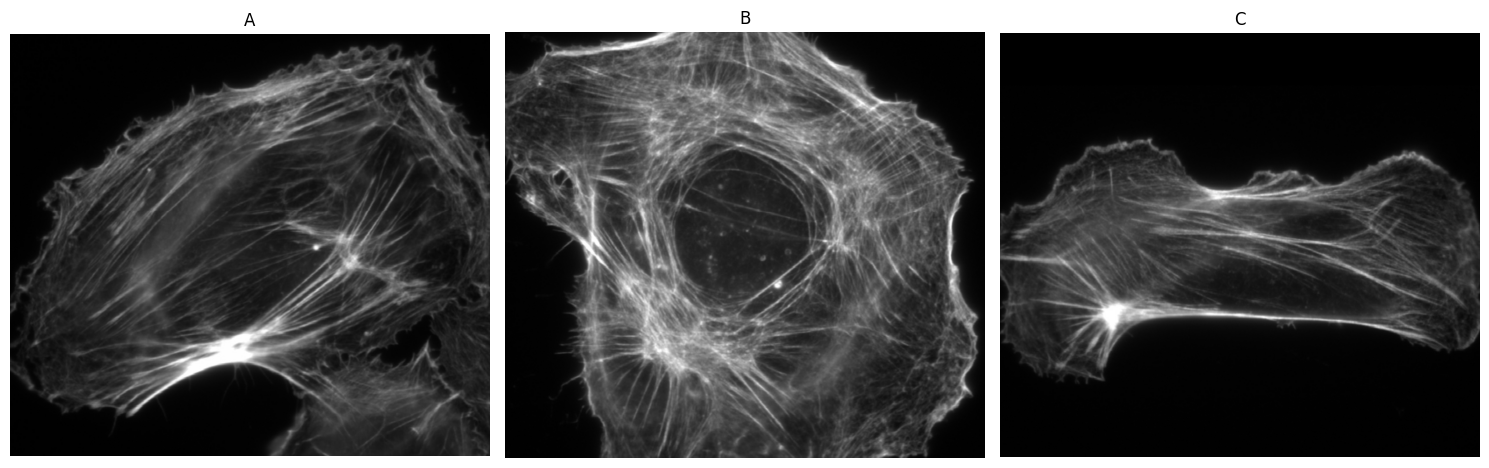

In [ ]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(A)
plt.title('A')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(B)
plt.title('B')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(C)
plt.title('C')
plt.axis('off')

plt.tight_layout()
plt.show()

# Apply a Canny edge detector to detect the edges

The Canny edge detector detects sharp brightness changes, suppresses areas with relatively low changes, and preserves regions of maximum change to produce thin outlines. It then links nearby edges together while discarding noise.

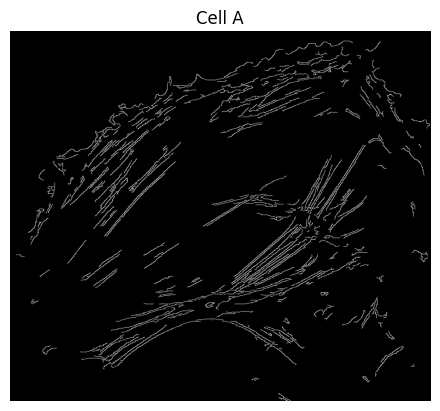

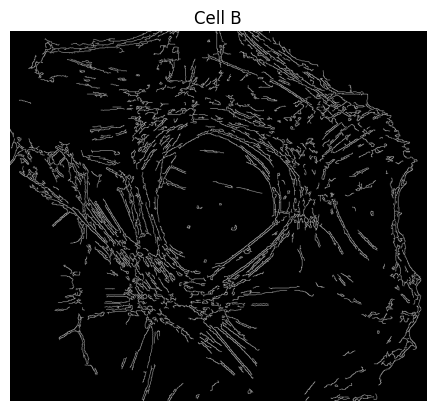

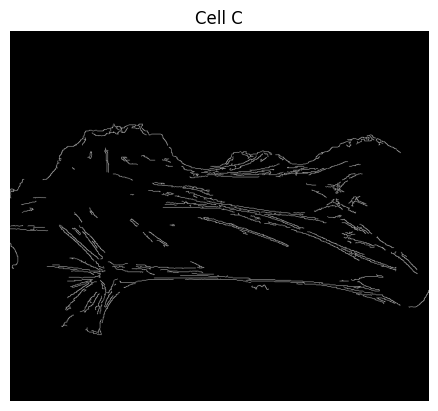

In [ ]:
edges_A = cv2.Canny(A, 50, 150, apertureSize=3)
edges_B = cv2.Canny(B, 50, 150, apertureSize=3)
edges_C = cv2.Canny(C, 50, 150, apertureSize=3)

# Display
plt.imshow(edges_A, cmap='gray')
plt.title("Cell A")
plt.axis('off')
plt.show()

plt.imshow(edges_B, cmap='gray')
plt.title("Cell B")
plt.axis('off')
plt.show()

plt.imshow(edges_C, cmap='gray')
plt.title("Cell C")
plt.axis('off')
plt.show()


# Obtain straight lines and calculate means & standard deviations of line orientations

In [ ]:
# Define functions
def process_lines(lines, img):
  img_c = img.copy()
  angles = []
  if len(lines) != 0:
    for line in lines:
      rho, theta = line[0]
      angles.append(theta) # theta is in radians
      a = np.cos(theta)
      b = np.sin(theta)
      x0 = a * rho
      y0 = b * rho
      x1 = int(x0 + 1000 * (-b))
      y1 = int(y0 + 1000 * (a))
      x2 = int(x0 - 1000 * (-b))
      y2 = int(y0 - 1000 * (a))
      cv2.line(img_c, (x1, y1), (x2, y2), (0, 0, 255), 1)
  else:
    print("No lines detected")

  return img_c, angles

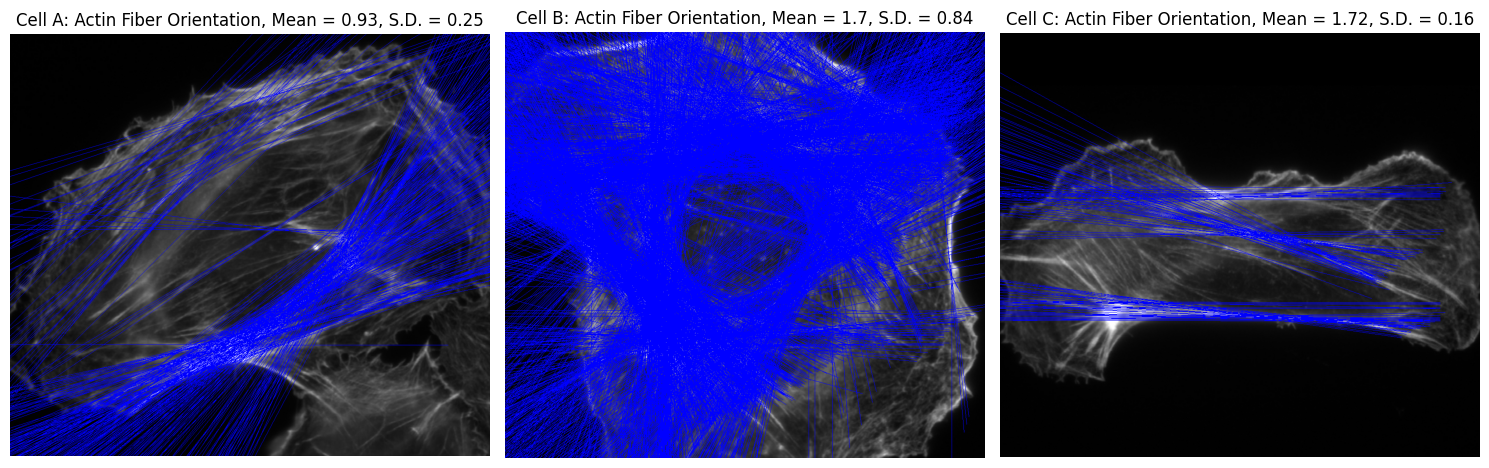

In [ ]:
# Calculate lines
lines_A = cv2.HoughLines(edges_A, rho=1, theta=np.pi/180, threshold=100)
lines_B = cv2.HoughLines(edges_B, rho=1, theta=np.pi/180, threshold=100)
lines_C = cv2.HoughLines(edges_C, rho=1, theta=np.pi/180, threshold=100)

img_A, angles_A = process_lines(lines_A, A)
img_B, angles_B = process_lines(lines_B, B)
img_C, angles_C = process_lines(lines_C, C)

mean_A, stv_A = circmean(angles_A), circstd(angles_A) # expressed in radians
mean_B, stv_B = circmean(angles_B), circstd(angles_B)
mean_C, stv_C = circmean(angles_C), circstd(angles_C)

# Display results
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_A)
plt.title(f"Cell A: Actin Fiber Orientation, Mean = {str(round(mean_A,2))}, S.D. = {str(round(stv_A,2))}")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img_B)
plt.title(f"Cell B: Actin Fiber Orientation, Mean = {str(round(mean_B,2))}, S.D. = {str(round(stv_B,2))}")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(img_C)
plt.title(f"Cell C: Actin Fiber Orientation, Mean = {str(round(mean_C,2))}, S.D. = {str(round(stv_C,2))}")
plt.axis('off')

plt.tight_layout()
plt.show()

# Experiment!
Try varying the threshold values and rho values to see the effect on the final Hough lines detected. <br>

From [OpenCV's documentation](https://docs.opencv.org/3.4/d9/db0/tutorial_hough_lines.html)
> *rho* : The resolution of the parameter r in pixels. <br>
*threshold*: The minimum number of intersections to "*detect*" a line




In [ ]:
def interactive_actin_orientation(image_choice, threshold_val, rho_val):
    # Select the appropriate image and its edges based on user's choice
    # These variables are assumed to be loaded from previous cells (A_act, B_act, C_act, edges_A, edges_B, edges_C)
    if image_choice == "Cell A":
        current_img = A.copy()
        current_edges = edges_A
    elif image_choice == "Cell B":
        current_img = B.copy()
        current_edges = edges_B
    elif image_choice == "Cell C":
        current_img = C.copy()
        current_edges = edges_C
    else:
        print("Invalid image choice.")
        return

    # Apply Hough Transform
    lines = cv2.HoughLines(current_edges, rho_val, theta=np.pi/180, threshold=threshold_val)

    # Process image (calculate stats and draw lines) using the previously defined function
    img, angles = process_lines(lines, current_img)
    mean, stv = circmean(angles), circstd(angles)

    # Display results
    plt.figure(figsize=(10, 10))
    plt.imshow(img)
    if mean is not None and stv is not None:
        plt.title(f"{image_choice}: Actin Fiber Orientation, Mean = {str(round(mean,2))}, S.D. = {str(round(stv,2))}")
    else:
        plt.title(f"{image_choice}: No lines detected with current parameters")
    plt.axis('off')
    plt.show()

# Define image choices for the dropdown
actin_image_dict = {
    "Cell A": "Cell A",
    "Cell B": "Cell B",
    "Cell C": "Cell C"
}

# Create interactive widgets
_ = interact(interactive_actin_orientation,
             image_choice=Dropdown(options=actin_image_dict, description="Image"),
             threshold_val=IntSlider(min=1, max=200, step=1, value=100, description='Threshold'),
             rho_val=IntSlider(min=1, max=10, step=1, value=1, description='Rho')
             )

interactive(children=(Dropdown(description='Image', options={'Cell A': 'Cell A', 'Cell B': 'Cell B', 'Cell C':…

# Let's try the same for Probabilistic Hough Transform

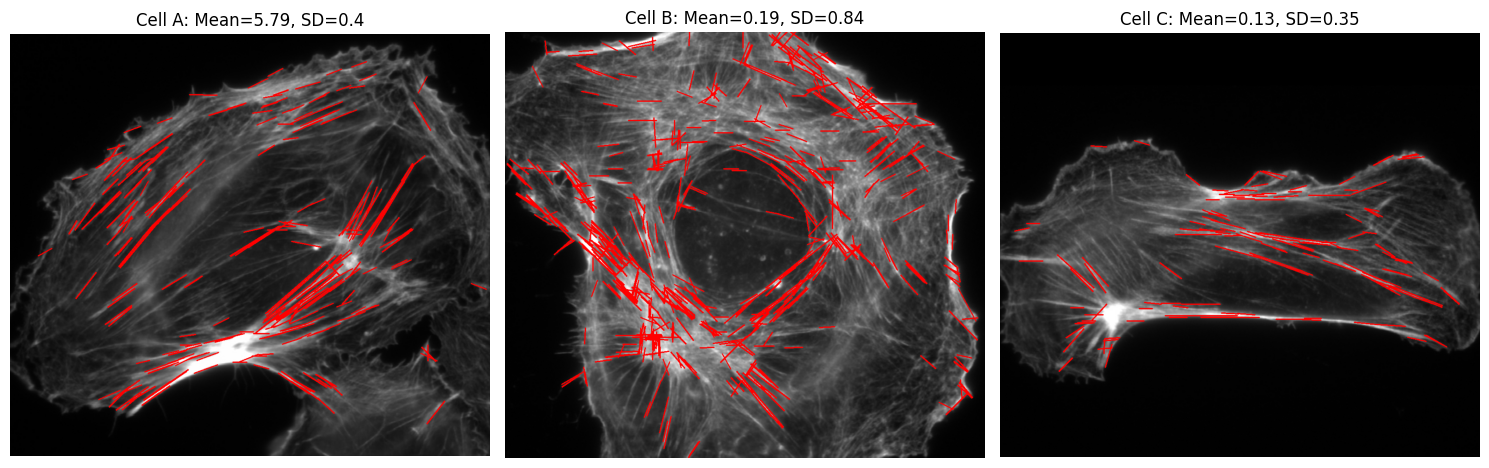

In [ ]:
# Define functions
def process_linesP(lines, img):
    img_c = img.copy()
    angles = []

    if lines is not None:
        for line in lines:
            x1, y1, x2, y2 = line[0]

            # Compute angle
            theta = np.arctan2((y2 - y1), (x2 - x1))
            angles.append(theta)

            # Draw line segment
            cv2.line(img_c, (x1, y1), (x2, y2), (0, 0, 255), 2)
    else:
        print("No lines detected")

    return cv2.cvtColor(img_c, cv2.COLOR_BGR2RGB), angles


# Calculate lines (probabilistic Hough)
lines_Ap = cv2.HoughLinesP(edges_A, 1, np.pi/180, threshold=50, minLineLength=30, maxLineGap=10)
lines_Bp = cv2.HoughLinesP(edges_B, 1, np.pi/180, threshold=50, minLineLength=30, maxLineGap=10)
lines_Cp = cv2.HoughLinesP(edges_C, 1, np.pi/180, threshold=50, minLineLength=30, maxLineGap=10)

img_Ap, angles_Ap = process_linesP(lines_Ap, A)
img_Bp, angles_Bp = process_linesP(lines_Bp, B)
img_Cp, angles_Cp = process_linesP(lines_Cp, C)

mean_Ap, stv_Ap = circmean(angles_Ap), circstd(angles_Ap)
mean_Bp, stv_Bp = circmean(angles_Bp), circstd(angles_Bp)
mean_Cp, stv_Cp = circmean(angles_Cp), circstd(angles_Cp)

# Display results (unchanged)
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_Ap)
plt.title(f"Cell A: Mean={round(mean_Ap,2)}, SD={round(stv_Ap,2)}")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img_Bp)
plt.title(f"Cell B: Mean={round(mean_Bp,2)}, SD={round(stv_Bp,2)}")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(img_Cp)
plt.title(f"Cell C: Mean={round(mean_Cp,2)}, SD={round(stv_Cp,2)}")
plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
def interactive_actin_orientationP(image_choice, threshold_val, min_line_length, max_line_gap):
    # Select image
    if image_choice == "Cell A":
        current_img = A.copy()
        current_edges = edges_A
    elif image_choice == "Cell B":
        current_img = B.copy()
        current_edges = edges_B
    elif image_choice == "Cell C":
        current_img = C.copy()
        current_edges = edges_C
    else:
        print("Invalid image choice.")
        return

    # Probabilistic Hough Transform
    lines = cv2.HoughLinesP(current_edges, 1, np.pi/180,
                            threshold=threshold_val,
                            minLineLength=min_line_length,
                            maxLineGap=max_line_gap)

    # Process lines (endpoint-based)
    img_c = current_img.copy()
    angles = []

    if lines is not None:
        for line in lines:
            x1, y1, x2, y2 = line[0]

            theta = np.arctan2((y2 - y1), (x2 - x1))
            angles.append(theta)

            cv2.line(img_c, (x1, y1), (x2, y2), (0, 0, 255), 2)

        mean, stv = circmean(angles), circstd(angles)
    else:
        mean, stv = None, None

    img_c = cv2.cvtColor(img_c, cv2.COLOR_BGR2RGB)

    # Display
    plt.figure(figsize=(10, 10))
    plt.imshow(img_c)
    if mean is not None:
        plt.title(f"{image_choice}: Mean={round(mean,2)}, SD={round(stv,2)}")
    else:
        plt.title(f"{image_choice}: No lines detected")
    plt.axis('off')
    plt.show()


# Widgets
_ = interact(interactive_actin_orientationP,
             image_choice=Dropdown(options=["Cell A","Cell B","Cell C"], description="Image"),
             threshold_val=IntSlider(min=1, max=200, step=1, value=50, description='Threshold'),
             min_line_length=IntSlider(min=10, max=200, step=5, value=30, description='Min Length'),
             max_line_gap=IntSlider(min=0, max=50, step=1, value=10, description='Max Gap')
             )

interactive(children=(Dropdown(description='Image', options=('Cell A', 'Cell B', 'Cell C'), value='Cell A'), I…